In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
import seaborn as sns

In [3]:
x,y = make_classification(n_samples=1000, n_redundant=0, n_clusters_per_class=2, random_state=42)

In [4]:
x

array([[ 1.56968568, -0.52489257, -1.68077962, ...,  2.93032029,
         0.05262213,  1.84580132],
       [ 0.31982306,  0.43568311, -0.52345243, ...,  0.38213128,
        -0.54457293, -0.99069751],
       [ 0.39397523,  1.49503031, -0.80311083, ...,  0.2354558 ,
        -0.80765056, -3.68836529],
       ...,
       [ 1.41945568, -1.28760528, -0.50286875, ..., -0.59963999,
         0.85159105,  0.411953  ],
       [-1.20830352, -0.05683685,  0.37120676, ..., -3.32111456,
        -0.08187418, -0.59022197],
       [-0.7803766 ,  0.00400126,  0.03522531, ...,  0.35351398,
         0.45740074,  0.18955986]])

In [5]:
y

array([1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0,
       1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1,
       0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0,

In [6]:
pd.DataFrame(x)[0]

0      1.569686
1      0.319823
2      0.393975
3      0.193662
4     -1.180460
         ...   
995    1.715118
996   -0.987858
997    1.419456
998   -1.208304
999   -0.780377
Name: 0, Length: 1000, dtype: float64

<Axes: xlabel='0', ylabel='1'>

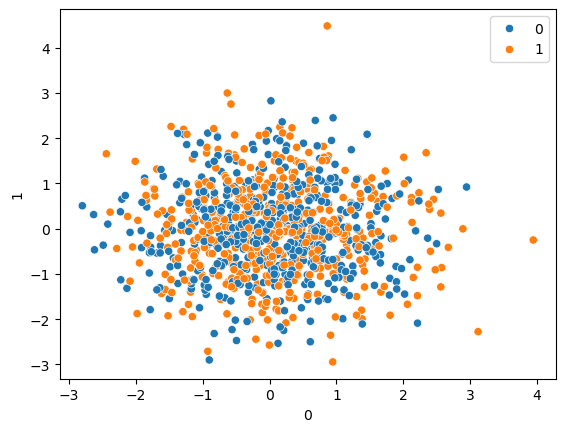

In [8]:
sns.scatterplot(
    x=pd.DataFrame(x)[0],
    y=pd.DataFrame(x)[1],
    hue=y,
    
)

In [9]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=10)

from sklearn.svm import SVC
svc = SVC(kernel='linear')
svc.fit(x_train, y_train)
svc.coef_
y_pred = svc.predict(x_test)
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.91      0.90      0.90       125
           1       0.90      0.91      0.90       125

    accuracy                           0.90       250
   macro avg       0.90      0.90      0.90       250
weighted avg       0.90      0.90      0.90       250

[[112  13]
 [ 11 114]]


In [10]:
rbf = SVC(kernel = 'rbf')
rbf.fit(x_train, y_train)
y_pred_rbf = rbf.predict(x_test)
print(classification_report(y_test, y_pred_rbf))
print(confusion_matrix(y_test, y_pred_rbf))


              precision    recall  f1-score   support

           0       0.90      0.86      0.88       125
           1       0.87      0.90      0.89       125

    accuracy                           0.88       250
   macro avg       0.88      0.88      0.88       250
weighted avg       0.88      0.88      0.88       250

[[108  17]
 [ 12 113]]


In [11]:
polynomial = SVC(kernel='poly')
polynomial.fit(x_train, y_train)
y_pred_poly = polynomial.predict(x_test)
print(classification_report(y_test, y_pred_poly))
print(confusion_matrix(y_test, y_pred_poly))

              precision    recall  f1-score   support

           0       0.83      0.88      0.86       125
           1       0.87      0.82      0.85       125

    accuracy                           0.85       250
   macro avg       0.85      0.85      0.85       250
weighted avg       0.85      0.85      0.85       250

[[110  15]
 [ 22 103]]


In [12]:
sigmoid = SVC(kernel='sigmoid')
sigmoid.fit(x_train, y_train)
y_pred_sigmoid = sigmoid.predict(x_test)
print(classification_report(y_test, y_pred_sigmoid))
print(confusion_matrix(y_test, y_pred_sigmoid))

              precision    recall  f1-score   support

           0       0.92      0.90      0.91       125
           1       0.90      0.92      0.91       125

    accuracy                           0.91       250
   macro avg       0.91      0.91      0.91       250
weighted avg       0.91      0.91      0.91       250

[[112  13]
 [ 10 115]]


In [15]:
#Hyper parameter tuning with SVC
from sklearn.model_selection import GridSearchCV
# defingin parameters range

param_grid = {
    'C':[0.1,1,10,100,1000],
    'gamma':[1,0.1,0.01,0.001,0.0001],
    'kernel':['rbf']    
}

grid = GridSearchCV(SVC(),param_grid = param_grid, refit = True, cv= 5,verbose=3)

grid.fit(x_train,y_train)

grid.best_params_

y_pred_grid = grid.predict(x_test)
print(classification_report(y_test, y_pred_grid))
print(confusion_matrix(y_test, y_pred_grid))

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.500 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.500 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.500 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.507 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.507 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.667 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.740 total time=   0.0s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.600 total time=   0.0s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.833 total time=   0.0s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.873 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.860 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

In [ ]:
# C= regularization parameter
# gamma = Influence of a single data point
# Total combination:
# 5(C) * 5(gamma)* 1(kernel) = 25 models will be trained
# Here we used GridSearchCV to perform hyperparameter tuning
# It checks all combos of given parameters using dv and selects the model with best performance